In [1]:
!pip install jsonschema tenacity tqdm openai -q

zsh:1: command not found: pip


In [5]:
from getpass import getpass
import sys
import json
import time
import random
import re
import os
import zipfile
from datetime import datetime
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from openai import OpenAI
from tqdm import tqdm
import jsonschema
import matplotlib.pyplot as plt

In [ ]:
API_KEY = getpass("API ключ: ")
if not API_KEY:
    sys.exit(1)

with open("exercises.json", encoding="utf-8") as f:
    CATALOG = json.load(f)
CATALOG_BY_ID = {ex["id"]: ex for ex in CATALOG}
with open("schema.json", encoding="utf-8") as f:
    SCHEMA = json.load(f)

def build_compact_catalog() -> str:
    lines = []
    for ex in CATALOG:
        contra = ",".join(ex["contraindications"]) if ex["contraindications"] else "none"
        lines.append(f"{ex['id']}:{ex['type']}|{ex['muscleGroup']}|{ex['difficulty']}|{contra}")
    return "\n".join(lines)

CATALOG_COMPACT = build_compact_catalog()
TOTAL = 3500

In [7]:
SYSTEM_PROMPT = f"""You are a fitness AI trainer. Create valid JSON workouts.

Available exercises (id:type|muscle|level|contra):
{CATALOG_COMPACT}

CRITICAL RULES:
1. Return ONLY valid JSON, no other text
2. Every exercise MUST include ALL required fields for its type
3. Use ONLY exercise_id from list above

REQUIRED FIELDS BY TYPE:

STRENGTH exercises require:
  "exercise_id": "id from list"
  "exercise_type": "strength"
  "sets": number (1-10)
  "reps": number (1-50)
  "weight_kg": null or number

CARDIO exercises require:
  "exercise_id": "id from list"
  "exercise_type": "cardio"
  "duration_minutes": number (1-120)
  "pace": "walk" or "jog" or "run" or "sprint" or "recovery"

YOGA exercises require:
  "exercise_id": "id from list"
  "exercise_type": "yoga"
  "hold_seconds": number (5-300)
  "breath_count": number (1-20)

Example of valid response:
{{
  "workout_name": "Morning Yoga Flow",
  "type": "yoga",
  "duration_min": 30,
  "exercises": [
    {{
      "exercise_id": "downward-dog",
      "exercise_type": "yoga",
      "hold_seconds": 30,
      "breath_count": 5
    }}
  ]
}}

Generate workout now:"""

In [ ]:
class PromptGenerator:
    def __init__(self):
        self.levels = ["beginner", "intermediate", "advanced"]
        self.levels_desc = {
            "beginner": ["новичок", "только начинаю", "мало опыта", "базовый уровень", "первые шаги", "начинающий", "нулевой уровень", "с нуля"],
            "intermediate": ["средний уровень", "опытный", "занимаюсь регулярно", "не новичок", "продолжающий", "уверенный", "база есть", "не первый год"],
            "advanced": ["продвинутый", "спортсмен", "высокий уровень", "опытный атлет", "профессиональный", "эксперт", "продвинутый уровень", "спортивный разряд"]
        }

        self.types = ["strength", "cardio", "yoga"]
        self.weights = [0.4, 0.3, 0.3]
        self.muscles = {
            "strength": ["legs", "chest", "back", "shoulders", "core", "arms", "full_body"],
            "cardio": ["full_body", "legs"],
            "yoga": ["full_body", "back", "core", "legs"]
        }
        self.muscles_ru = {
            "legs": ["ног", "нижней части тела", "квадрицепсов", "ягодиц", "бедер", "икр", "бицепса бедра", "ног и ягодиц", "нижних конечностей"],
            "chest": ["груди", "грудных мышц", "верхней части груди", "нижней части груди", "пекторальных", "грудного отдела", "пекторальных мышц"],
            "back": ["спины", "широчайших", "трапеций", "ромбовидных", "поясницы", "мышц кора спины", "спины и поясницы", "широчайших мышц"],
            "shoulders": ["плеч", "дельт", "плечевого пояса", "дельтовидных", "трапеций плеч", "плечевых мышц", "дельтовидных мышц"],
            "core": ["пресса", "кора", "живота", "мышц корпуса", "косых мышц", "поясницы", "брюшного пресса", "мышц живота"],
            "arms": ["рук", "бицепсов", "трицепсов", "предплечий", "плеч рук", "брахиалиса", "рук и плеч", "верхних конечностей"],
            "full_body": ["всего тела", "всех групп мышц", "полноценную", "комплексную", "фуллбади", "все тело целиком", "полную", "комплексную тренировку"]
        }
        self.goals = {
            "strength": [
                "набрать мышечную массу", "увеличить силу", "стать сильнее",
                "прогрессировать в весах", "сделать тело рельефным", "улучшить форму",
                "накачаться", "увеличить мышечный объем", "улучшить силовые показатели",
                "подтянуть фигуру", "укрепить мышцы", "развить силу", "привести себя в форму",
                "улучшить тонус", "сделать мышцы плотнее", "улучшить спортивную форму",
                "нарастить массу", "увеличить объем", "улучшить силовую выносливость"
            ],
            "cardio": [
                "похудеть", "сжечь жир", "улучшить выносливость",
                "укрепить сердечно-сосудистую систему", "сбросить вес", "повысить тонус",
                "улучшить работу сердца", "снизить вес", "подтянуть тело", "улучшить дыхание",
                "повысить энергию", "ускорить метаболизм", "сжечь калории", "улучшить аэробную форму",
                "снизить процент жира", "улучшить обмен веществ", "увеличить кислородный долг"
            ],
            "yoga": [
                "расслабиться", "снять стресс", "улучшить гибкость", "обрести спокойствие",
                "восстановиться", "улучшить осанку", "научиться дышать", "медитировать",
                "снять напряжение", "успокоить ум", "найти баланс", "повысить осознанность",
                "укрепить тело", "восстановить энергию", "улучшить самочувствие", "обрести гармонию",
                "улучшить подвижность", "снять зажимы", "улучшить кровообращение"
            ]
        }
        self.request_styles = [
            "сделай", "составь", "нужна", "хочу", "напиши", "подбери", "помоги с",
            "посоветуй", "дай", "создай", "можешь составить", "пожалуйста, сделай",
            "нужно создать", "требуется", "ищу", "подскажи", "рекомендуй", "предложи",
            "надо", "хотел бы получить", "интересует", "будьте добры", "мог бы ты",
            "не подскажешь", "есть возможность", "возможно ли", "подкинь идею", "организуй"
        ]
        self.time_of_day = ["утренняя", "дневная", "вечерняя", "ранняя утренняя", "поздняя вечерняя", "ночная", "обеденная", "предрассветная"]
        self.locations = ["дома", "в зале", "на улице", "в парке", "в гостинице", "в офисе", "на даче", "в путешествии", "на пляже", "в лесу", "на стадионе"]
        self.weekdays = ["в понедельник", "во вторник", "в среду", "в четверг", "в пятницу", "в субботу", "в воскресенье"]
        self.equipment = {
            "home": ["без инвентаря", "с гантелями", "с резинкой", "с ковриком", "с бутылками воды", "с рюкзаком", "со стулом", "с полотенцем", "с экспандером", "с блинами", "с гирей"],
            "gym": ["со штангой", "с гантелями", "на тренажерах", "с блоками", "с гирями", "на кроссовере", "на Смите", "с блинами", "с грифом", "на скамье", "с турником"],
            "outdoor": ["на турнике", "на брусьях", "со скакалкой", "с резиной", "на стадионе", "в лесу", "на пляже", "на площадке", "на перекладине", "с партнером"]
        }
        self.time_constraints = [
            "быстро", "за 20 минут", "не больше часа", "в обеденный перерыв", "до работы",
            "после работы", "за 30 минут", "за 45 минут", "за 15 минут", "на утро",
            "на вечер", "между делами", "в перерыве", "без потери времени", "эффективно",
            "максимально быстро", "за час", "за полчаса", "пока есть окно", "до завтрака"
        ]
        self.yoga_focus = [
            "гибкость", "расслабление", "баланс", "сила", "дыхание", "медитация",
            "восстановление", "вытяжение", "скручивания", "прогибы", "наклоны",
            "позы стоя", "баланс на руках", "перевернутые позы", "динамика", "статику",
            "виньясы", "асаны", "пранаяму", "концентрацию"
        ]
        self.cardio_paces = ["walk", "jog", "run", "sprint", "recovery"]
        self.cardio_paces_ru = {
            "walk": ["шаг", "ходьба", "прогулка", "быстрый шаг", "активная ходьба", "скандинавская ходьба"],
            "jog": ["бег трусцой", "легкий бег", "джоггинг", "расслабленный бег", "спокойный бег"],
            "run": ["бег", "средний темп", "бег на пульсе", "спортивный бег", "аэробный бег"],
            "sprint": ["спринт", "максимальный темп", "рывок", "ускорение", "взрывной бег"],
            "recovery": ["восстановление", "отдых", "шаг восстановления", "активный отдых", "заминка"]
        }
        self.intensities = ["легкая", "средняя", "высокая", "низкая", "умеренная", "максимальная", "средне-высокая", "средне-низкая"]
        self.moods = ["устал", "полон энергии", "нет настроения", "хочу активность", "хочу спокойствие", "вымотан", "бодр", "сонный", "в тонусе", "на подъеме"]
        self.workout_formats = ["круговая", "интервальная", "непрерывная", "суперсетами", "дропсетами", "пирамида", "табата", "HIIT", "LISS", "EMS", "функциональная"]
        self.cardio_variations = [
            "беговая", "велосипед", "интервальная", "LISS", "HIIT", "степ-аэробика",
            "танцевальная", "прыжковая", "на эллипсе", "гребля", "плавание", "скакалка",
            "берпи", "бурпи", "скиппинг", "челночный бег", "фартлек", "темповая"
        ]
        self.punctuation = ["!", "!!", "...", "?", "?!", "!!!"]
        self.emojis = ["💪", "🔥", "🏋️", "🧘", "🏃", "💯", "⚡", "🎯", "✅", "⭐"]
        self.slang = {
            "strength": ["прокачка", "пампа", "масса набор", "железо", "качалово", "тяжелый", "база", "изоляция"],
            "cardio": ["жиросжигание", "кардио-сессия", "аэробика", "кардио-забег", "кардио-марафон", "разгон пульса"],
            "yoga": ["потягушки", "расслабон", "медитация-пауза", "йога-поток", "практика-антистресс", "гибкость-буст"]
        }

    def generate(self) -> Tuple[str, Dict]:
        workout_type = random.choices(self.types, weights=self.weights)[0]
        level = random.choice(self.levels)
        level_ru = random.choice(self.levels_desc[level])
        style = random.choice(self.request_styles)
        time_of_day = random.choice(self.time_of_day)
        location = random.choice(self.locations)
        weekday = random.choice(self.weekdays)
        intensity = random.choice(self.intensities)
        mood = random.choice(self.moods)
        format_type = random.choice(self.workout_formats)
        punct = random.choice(self.punctuation)
        add_emoji = random.random() < 0.2
        add_slang = random.random() < 0.15
        use_caps = random.random() < 0.1
        params = {"level": level}
        if workout_type == "yoga":
            prompt = self._generate_yoga_prompt(style, time_of_day, location, weekday, intensity, mood, level_ru, format_type, punct, use_caps)
            if add_slang and "yoga" in self.slang:
                prompt += f" {random.choice(self.slang['yoga'])}"
        elif workout_type == "cardio":
            prompt = self._generate_cardio_prompt(style, time_of_day, location, weekday, intensity, mood, format_type, level_ru, punct, use_caps)
            if add_slang and "cardio" in self.slang:
                prompt += f" {random.choice(self.slang['cardio'])}"
        else:
            prompt = self._generate_strength_prompt(style, time_of_day, location, weekday, intensity, mood, format_type, level_ru, punct, use_caps)
            if add_slang and "strength" in self.slang:
                prompt += f" {random.choice(self.slang['strength'])}"
        if add_emoji:
            prompt = f"{random.choice(self.emojis)} {prompt}"
        if random.random() < 0.1:
            starters = ["Срочно!", "Пожалуйста!", "Очень нужно!", "Вопрос:", "Просьба:"]
            prompt = f"{random.choice(starters)} {prompt}"

        params.update(self._get_duration_params(workout_type))

        return self._add_contraindications(prompt, params)

    def _get_duration_params(self, workout_type: str) -> Dict:
        if workout_type == "yoga":
            return {"time_min": random.choice([10, 15, 20, 25, 30, 40, 45, 50, 60, 75, 90])}
        elif workout_type == "cardio":
            return {"time_min": random.choice([10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])}
        else:
            return {"time_min": random.choice([15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 75, 90])}

    def _generate_strength_prompt(self, style, time_of_day, location, weekday, intensity, mood, format_type, level_ru, punct, use_caps):
        muscle = random.choice(self.muscles["strength"])
        muscle_ru = random.choice(self.muscles_ru[muscle])
        duration = random.choice([15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 75, 90])
        goal = random.choice(self.goals["strength"])

        loc_key = location.split()[0] if location in ["дома", "в зале", "на улице"] else "home"
        equipment = random.choice(self.equipment.get(loc_key, self.equipment["home"]))
        time_constraint = random.choice(self.time_constraints)
        templates = [
            f"{style} тренировку на {muscle_ru}, {duration} минут, {level_ru} уровень",
            f"{style.capitalize()} программу для {muscle_ru}, {time_constraint}, {level_ru} уровень",
            f"Нужна {time_of_day} силовая для {muscle_ru}, цель - {goal}",
            f"Хочу {goal}. Тренировка {location}, {duration} мин, уровень {level_ru}",
            f"Помоги с тренировкой на {muscle_ru}, есть {equipment}, {duration} минут",
            f"{style} {format_type} тренировку для {muscle_ru}, {duration} мин, {level_ru}",
            f"Нужно {goal}, тренировка {location} на {duration} минут, {intensity} интенсивность",
            f"{style} эффективную тренировку для {muscle_ru}, уровень {level_ru}, {time_constraint}",
            f"Ищу {time_of_day} силовую на {duration} минут, фокус на {muscle_ru}, {weekday}",
            f"{style.capitalize()} план для {muscle_ru}, чтобы {goal}, за {duration} мин, {level_ru}",
            f"Я {mood}, нужна тренировка на {muscle_ru}, {duration} минут, {level_ru} уровень",
            f"Хочу {goal}. Чувствую себя {mood}. Тренировка {location}, {duration} мин",
            f"{style} круг на {muscle_ru}, {duration} мин, {intensity} интенсивность, {level_ru}",
            f"Нужна {time_of_day} {format_type} тренировка для {muscle_ru}, цель - {goal}, {duration} мин",
            f"{style} программу {weekday}, фокус на {muscle_ru}, {level_ru} уровень, есть {equipment}",
            f"Ищу эффективную тренировку для {muscle_ru}, чтобы {goal}, {time_constraint}, {level_ru}",
            f"Помоги с {format_type} тренировкой на {muscle_ru}, {duration} мин, {level_ru}, {intensity} интенсивность",
            f"Хочу {goal} и {format_type} тренировку для {muscle_ru}, {duration} мин, {location}",
            f"Можешь составить план для {muscle_ru}? Уровень {level_ru}, время {duration} мин",
            f"Как лучше тренировать {muscle_ru}? Нужна тренировка на {duration} минут, {level_ru}",
            f"Посоветуй {format_type} тренировку для {muscle_ru}, {duration} мин, {level_ru} уровень",
            f"Что посоветуешь для {muscle_ru}? Цель - {goal}, время {duration} минут, {location}",
            f"Составь {format_type} тренировку! {muscle_ru}, {duration} мин, {level_ru}",
            f"Дай программу на {muscle_ru}! Хочу {goal}, время {duration} мин, {location}",
            f"Создай {format_type} комплекс для {muscle_ru}, {duration} мин, {intensity} интенсивность",
            f"Нужно прокачать {muscle_ru} за {duration} минут, уровень {level_ru}",
            f"Цель - {goal}. Время на тренировку {duration} мин, {location}, {level_ru}",
            f"Сделай упор на {muscle_ru}, {duration} минут, {level_ru}, {format_type} формат",
            f"Тренировка для {muscle_ru}, {duration} мин, {intensity} интенсивность, {level_ru}",
            f"Помоги с прогрессом в {muscle_ru}, тренировка {duration} мин, {level_ru}"
        ]
        prompt = random.choice(templates)
        if use_caps and len(prompt) > 10:
            prompt = prompt.upper()
        return prompt + punct

    def _generate_cardio_prompt(self, style, time_of_day, location, weekday, intensity, mood, format_type, level_ru, punct, use_caps):
        duration = random.choice([10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])
        goal = random.choice(self.goals["cardio"])
        cardio_type = random.choice(self.cardio_variations)
        pace = random.choice(self.cardio_paces)
        pace_ru = random.choice(self.cardio_paces_ru[pace])
        templates = [
            f"{style} кардио-тренировку на {duration} минут, {level_ru} уровень",
            f"Нужна {time_of_day} кардио сессия, цель - {goal}",
            f"Хочу {goal}. {cardio_type} тренировка {location}, {duration} минут",
            f"{style.capitalize()} интервальную кардио на {duration} мин, {level_ru} уровень",
            f"{style.capitalize()} LISS кардио для {goal}, {duration} мин",
            f"Нужно улучшить выносливость, тренировка {duration} минут, темп {pace_ru}, {level_ru}",
            f"{style} программу для сердечно-сосудистой системы, {duration} мин, {pace_ru}",
            f"Ищу {time_of_day} кардио на {duration} минут, {cardio_type}, темп {pace_ru}",
            f"Хочу {goal} за {duration} минут, {level_ru} уровень, {location}, темп {pace_ru}",
            f"{style} {format_type} кардио на {duration} мин, {intensity} интенсивность, {level_ru}",
            f"Нужна {time_of_day} {format_type} тренировка для {goal}, {duration} мин",
            f"Хочу {goal} с помощью {cardio_type}, {duration} минут, {format_type} формат",
            f"Я {mood}, нужно кардио на {duration} минут, {level_ru} уровень, темп {pace_ru}",
            f"Чувствую себя {mood}, хочу {goal}, тренировка {duration} мин, {location}",
            f"{style} {format_type} кардио {weekday}, цель - {goal}, {duration} мин, {level_ru}",
            f"Ищу эффективную кардио тренировку, чтобы {goal}, {duration} мин, темп {pace_ru}",
            f"Помоги с {format_type} кардио на {duration} мин, {level_ru}, {intensity} интенсивность",
            f"Хочу {goal} и {format_type} кардио, {duration} мин, {location}, темп {pace_ru}",
            f"Нужна {time_of_day} кардио сессия {weekday}, {duration} мин, {intensity} интенсивность",
            f"Как сделать кардио для {goal}? Нужна тренировка на {duration} минут",
            f"Посоветуй {cardio_type} тренировку, {duration} мин, {level_ru} уровень",
            f"Что лучше для {goal}? Кардио на {duration} минут, {intensity} интенсивность",
            f"Создай кардио тренировку! {duration} мин, {level_ru}, темп {pace_ru}",
            f"Дай программу для {goal}! Время {duration} мин, {cardio_type}",
            f"Составь {format_type} кардио комплекс, {duration} мин, {intensity} интенсивность",
            f"Хочу сжечь калории за {duration} минут, уровень {level_ru}, {cardio_type}",
            f"Нужна активная кардио сессия на {duration} мин, пульсовая зона {intensity}",
            f"Цель - {goal}. Время {duration} минут, {cardio_type}, {location}",
            f"Помоги с {cardio_type}, {duration} мин, темп {pace_ru}, {level_ru}"
        ]
        prompt = random.choice(templates)
        if use_caps and len(prompt) > 10:
            prompt = prompt.upper()
        return prompt + punct

    def _generate_yoga_prompt(self, style, time_of_day, location, weekday, intensity, mood, level_ru, format_type, punct, use_caps):
        duration = random.choice([10, 15, 20, 25, 30, 40, 45, 50, 60, 75, 90])
        goal = random.choice(self.goals["yoga"])
        focus = random.choice(self.yoga_focus)
        templates = [
            f"{style} йога-практику на {duration} минут, фокус на {focus}",
            f"Нужна {time_of_day} йога для {goal}, уровень {level_ru}",
            f"Хочу {goal}. Йога {location}, {duration} минут",
            f"{style.capitalize()} мягкую йогу на {duration} мин, {level_ru} уровень",
            f"Помоги с йога-комплексом для {focus}, {duration} минут",
            f"{style.capitalize()} последовательность для {goal}, {duration} мин, {intensity} интенсивность",
            f"Нужно {goal}, практика {duration} минут, {intensity} практика",
            f"{style} {intensity} йогу на {duration} минут, фокус {focus}",
            f"Я {mood}, нужна йога на {duration} минут, чтобы {goal}",
            f"Чувствую себя {mood}, хочу {goal}, практика {duration} мин",
            f"{style} восстановительную йогу, я {mood}, {duration} минут",
            f"{style} {time_of_day} йога-практику {weekday}, фокус на {focus}, {duration} мин",
            f"Ищу йогу для {goal}, {duration} минут, {level_ru} уровень, {intensity} интенсивность",
            f"Помоги с {focus} йогой, {duration} мин, {level_ru}, чтобы {goal}",
            f"Хочу {goal} через {focus} йогу, {duration} минут, {location}, {level_ru}",
            f"Нужна {time_of_day} сессия {weekday}, {duration} мин, фокус {focus}",
            f"Какую йогу выбрать для {goal}? Нужна практика на {duration} минут",
            f"Посоветуй практику для {focus}, {duration} мин, {level_ru} уровень",
            f"Что лучше для {goal}? Йога {duration} минут, фокус на {focus}",
            f"Можешь составить {focus} комплекс? Уровень {level_ru}, время {duration} мин",
            f"Создай йога-комплекс! {focus}, {duration} мин, {level_ru}",
            f"Дай практику для {goal}! Время {duration} мин, {focus}",
            f"Составь {intensity} йога-последовательность, {duration} мин, фокус {focus}",
            f"Сделай {time_of_day} йога-поток, {duration} мин, {intensity} интенсивность",
            f"Нужна {format_type} йога-практика, {duration} мин, фокус {focus}",
            f"Хочу растяжку и {goal}, {duration} минут, {level_ru}",
            f"Помоги с {focus} для начинающих, {duration} мин, {level_ru}"
        ]
        prompt = random.choice(templates)
        if use_caps and len(prompt) > 10:
            prompt = prompt.upper()

        return prompt + punct
    def _add_contraindications(self, prompt: str, params: Dict) -> Tuple[str, Dict]:
        if random.random() < 0.35:
            injuries = {
                "knee_injury": ["колено", "колена", "коленях", "коленные суставы"],
                "shoulder_injury": ["плечо", "плеча", "плече", "плечевой сустав"],
                "lower_back_pain": ["спина", "спину", "поясница", "поясницу", "нижняя часть спины"],
                "wrist_injury": ["запястье", "запястья", "кисть", "кисти", "запястный сустав"],
                "neck_injury": ["шея", "шею", "шее", "шейный отдел"],
                "ankle_injury": ["голеностоп", "лодыжка", "лодыжку", "голеностопный сустав"],
                "high_blood_pressure": ["давление", "давлением", "гипертония", "повышенное давление"],
                "elbow_injury": ["локоть", "локтя", "локте", "локтевой сустав"],
                "pregnancy": ["беременность", "беременна", "ждем ребенка", "в положении"]
            }

            injury_en = random.choice(list(injuries.keys()))
            injury_ru = random.choice(injuries[injury_en])
            positions = [
                f", но есть травма {injury_ru}",
                f", берегите {injury_ru}",
                f", нельзя нагрузку на {injury_ru}",
                f" с учетом проблем с {injury_ru}",
                f", {injury_ru} болит",
                f", восстанавливаюсь после травмы {injury_ru}",
                f" (противопоказания: {injury_ru})",
                f", осторожно с {injury_ru}",
                f" с ограничениями: {injury_ru}",
                f", травма {injury_ru} беспокоит"
            ]
            prompt += random.choice(positions)
            params["contraindications"] = [injury_en]
        return prompt, params

In [ ]:
def validate_and_fix_workout(workout: Dict, user_params: Optional[Dict] = None) -> Tuple[bool, str, Dict]:
    if not workout:
        return False, "Empty workout", workout

    if "workout_name" not in workout or not workout["workout_name"]:
        workout["workout_name"] = f"{workout.get('type', 'workout').capitalize()} Session"

    if "type" not in workout or workout["type"] not in ["strength", "cardio", "yoga"]:
        return False, f"Invalid type: {workout.get('type')}", workout

    if "duration_min" not in workout or workout["duration_min"] < 5:
        workout["duration_min"] = random.choice([20, 30, 45])
    elif workout["duration_min"] > 120:
        workout["duration_min"] = 60

    if "exercises" not in workout or not workout["exercises"]:
        return False, "No exercises", workout
    try:
        jsonschema.validate(instance=workout, schema=SCHEMA)
    except jsonschema.ValidationError as e:
        print(f"  Schema warning: {e.message[:100]}")
    fixed_exercises = []
    exercise_ids = set()
    for ex in workout.get("exercises", []):
        eid = ex.get("exercise_id")
        if eid not in CATALOG_BY_ID:
            continue
        cat = CATALOG_BY_ID[eid]
        if cat["type"] != workout["type"]:
            continue
        if user_params and "contraindications" in user_params:
            user_contra = set(user_params["contraindications"])
            ex_contra = set(cat.get("contraindications", []))
            if user_contra & ex_contra:
                continue
        if eid in exercise_ids:
            continue
        exercise_ids.add(eid)
        fixed_ex = {
            "exercise_id": eid,
            "exercise_type": workout["type"],
        }
        t = workout["type"]
        if t == "strength":
            sets = ex.get("sets")
            if sets is None or not isinstance(sets, int) or sets < 1 or sets > 10:
                sets = random.choice([3, 4, 5])
            fixed_ex["sets"] = sets
            reps = ex.get("reps")
            if reps is None or not isinstance(reps, int) or reps < 1 or reps > 50:
                reps = random.choice([8, 10, 12, 15])
            fixed_ex["reps"] = reps
            weight = ex.get("weight_kg")
            if weight is not None and (not isinstance(weight, (int, float)) or weight < 0 or weight > 300):
                weight = None
            fixed_ex["weight_kg"] = weight
        elif t == "cardio":
            duration = ex.get("duration_minutes")
            if duration is None or not isinstance(duration, (int, float)) or duration < 1 or duration > 120:
                duration = random.choice([5, 10, 15, 20])
            fixed_ex["duration_minutes"] = int(duration)
            pace = ex.get("pace")
            valid_paces = ["walk", "jog", "run", "sprint", "recovery"]
            if pace not in valid_paces:
                pace = random.choice(valid_paces)
            fixed_ex["pace"] = pace
        elif t == "yoga":
            hold = ex.get("hold_seconds")
            if hold is None or not isinstance(hold, (int, float)) or hold < 5 or hold > 300:
                hold = random.choice([15, 30, 45, 60])
            fixed_ex["hold_seconds"] = int(hold)
            breath = ex.get("breath_count")
            if breath is None or not isinstance(breath, (int, float)) or breath < 1 or breath > 20:
                breath = random.choice([3, 5, 8, 10])
            fixed_ex["breath_count"] = int(breath)
        if ex.get("note") and isinstance(ex["note"], str) and len(ex["note"]) <= 200:
            fixed_ex["note"] = ex["note"]
        fixed_exercises.append(fixed_ex)
        if len(fixed_exercises) >= 12:
            break
    if len(fixed_exercises) == 0:
        return False, "No valid exercises", workout
    workout["exercises"] = fixed_exercises
    total_estimated = 0
    for ex in fixed_exercises:
        if workout["type"] == "strength":
            total_estimated += ex.get("sets", 3) * (ex.get("reps", 10) * 2 + 60)
        elif workout["type"] == "cardio":
            total_estimated += ex.get("duration_minutes", 10) * 60
        elif workout["type"] == "yoga":
            total_estimated += ex.get("hold_seconds", 30) + ex.get("breath_count", 5) * 4
    total_minutes = total_estimated // 60
    if total_minutes > 0 and abs(workout["duration_min"] - total_minutes) > 30:
        workout["duration_min"] = max(10, min(90, total_minutes))
    return True, "OK", workout

In [ ]:
class CerebrasGenerator:
    def __init__(self, api_key: str):
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.cerebras.ai/v1"
        )
        self.prompt_gen = PromptGenerator()

    def _extract_json(self, text: str) -> Optional[Dict]:
        if not text:
            return None
        text = re.sub(r'```json\s*', '', text)
        text = re.sub(r'```\s*', '', text)
        text = text.strip()
        try:
            start = text.find('{')
            if start == -1:
                return None
            depth = 0
            for i, ch in enumerate(text[start:], start):
                if ch == '{':
                    depth += 1
                elif ch == '}':
                    depth -= 1
                    if depth == 0:
                        obj = json.loads(text[start:i+1])
                        if "workout_name" in obj and "exercises" in obj:
                            return obj
                        break
        except json.JSONDecodeError:
            text = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', text)
        except:
            pass
        return None

    def generate(self) -> Tuple[Optional[Dict], Optional[Dict], Optional[str]]:
        for attempt in range(3):
            try:
                prompt, params = self.prompt_gen.generate()

                response = self.client.chat.completions.create(
                    model="llama3.1-8b",
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": prompt}
                    ],
                    temperature=random.uniform(0.2, 0.4),
                    max_tokens=2000
                )
                content = response.choices[0].message.content
                workout = self._extract_json(content)
                if not workout:
                    if attempt < 2:
                        time.sleep(1)
                        continue
                    return None, params, "No JSON found"
                ok, error, fixed_workout = validate_and_fix_workout(workout, params)
                if ok and fixed_workout["exercises"]:
                    return fixed_workout, params, None
                else:
                    if attempt < 2:
                        time.sleep(1)
                        continue
                    return None, params, error
            except Exception as e:
                if attempt < 2:
                    time.sleep(2)
                    continue
                return None, None, str(e)
        return None, None, "Max retries"

In [ ]:
class Metrics:
    def __init__(self):
        self.total = 0
        self.valid = 0
        self.types = defaultdict(int)
        self.contra = 0
        self.errors = []
        self.prompts = []

    def report(self):
        rate = self.valid/self.total*100 if self.total else 0
        types_str = ", ".join([f"{k}:{v}" for k, v in self.types.items()])
        unique_prompts = len(set(self.prompts)) if self.prompts else 0
        return f"Valid: {self.valid} | Errors: {self.total-self.valid} | 📈 Rate: {rate:.1f}%\n📋 Types: {types_str} | ⚠️ Contra: {self.contra}\n🎨 Unique prompts: {unique_prompts}"

def generate_dataset(total: int = 100) -> Tuple[List[Dict], Metrics]:

    gen = CerebrasGenerator(API_KEY)
    metrics = Metrics()
    examples = []
    pbar = tqdm(total=total, desc="Generating")
    for i in range(total):
        metrics.total += 1
        workout, params, error = gen.generate()
        if workout and workout.get("exercises"):
            prompt, _ = gen.prompt_gen.generate()
            metrics.prompts.append(prompt)
            example = {
                "messages": [
                    {"role": "system", "content": "You are a fitness AI trainer. Create safe workouts in JSON format."},
                    {"role": "user", "content": prompt},
                    {"role": "assistant", "content": json.dumps(workout, ensure_ascii=False)}
                ]
            }
            examples.append(example)
            metrics.valid += 1
            metrics.types[workout.get("type", "unknown")] += 1
            if params and params.get("contraindications"):
                metrics.contra += 1
            pbar.set_postfix({
                "valid": metrics.valid,
                "types": f"S:{metrics.types.get('strength',0)} C:{metrics.types.get('cardio',0)} Y:{metrics.types.get('yoga',0)}"
            })
        else:
            metrics.errors.append(error or "Unknown")
            pbar.set_postfix_str(f"{str(error)[:40] if error else 'Error'}")
        time.sleep(0.15)
        pbar.update(1)
    pbar.close()
    print("\n" + "="*50)
    print(metrics.report())
    print("="*50)
    if metrics.errors:
        print(f"\nSample error: {metrics.errors[-1][:200]}")
    return examples, metrics

def save_dataset(examples: List[Dict], metrics: Metrics):
    if not examples:
        return

    random.shuffle(examples)
    n = len(examples)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    splits = {
        "train": examples[:train_end],
        "val": examples[train_end:val_end],
        "test": examples[val_end:]
    }
    for name, data in splits.items():
        filename = f"{name}.jsonl"
        with open(filename, "w", encoding="utf-8") as f:
            for ex in data:
                clean = {"messages": ex["messages"]}
                f.write(json.dumps(clean, ensure_ascii=False) + "\n")
    with open("dataset_stats.json", "w", encoding="utf-8") as f:
        json.dump({
            "total": len(examples),
            "types": dict(metrics.types),
            "contraindications_count": metrics.contra,
            "success_rate": metrics.valid/metrics.total if metrics.total > 0 else 0,
            "unique_prompts": len(set(metrics.prompts)) if metrics.prompts else 0,
            "created_at": datetime.now().isoformat()
        }, f, indent=2)
    archive_name = f"workout_dataset_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
    files_to_zip = ["train.jsonl", "val.jsonl", "test.jsonl", "exercises.json", "schema.json", "dataset_stats.json"]
    with zipfile.ZipFile(archive_name, "w", zipfile.ZIP_DEFLATED) as zipf:
        for file in files_to_zip:
            if os.path.exists(file):
                zipf.write(file)
    try:
        from google.colab import files
        files.download(archive_name)
    except:
        print("Archive saved locally")

In [ ]:
examples, metrics = generate_dataset(TOTAL)
if examples:
    save_dataset(examples, metrics)
else:
    print("\nFailed to create examples")

In [1]:
def load_dataset(dataset_dir="."):
    data = {
        "train": [],
        "val": [],
        "test": []
    }
    for split_name in data.keys():
        file_path = os.path.join(dataset_dir, f"{split_name}.jsonl")
        if not os.path.exists(file_path):
            alt_path = f"{split_name}.jsonl"
            if os.path.exists(alt_path):
                file_path = alt_path
            else:
                continue
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    try:
                        data[split_name].append(json.loads(line))
                    except json.JSONDecodeError as e:
                        print(f"{file_path}: {e}")
    return data

In [2]:
def plot_coverage(data, catalog):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    type_counts = defaultdict(int)
    for split_name, examples in data.items():
        for ex in examples:
            try:
                assistant_msg = ex["messages"][2]["content"]
                workout = json.loads(assistant_msg)
                type_counts[workout.get("type", "unknown")] += 1
            except:
                pass

    types = list(type_counts.keys())
    counts = list(type_counts.values())
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    axes[0].bar(types, counts, color=colors[:len(types)])
    axes[0].set_title('Распределение по типам тренировок')
    axes[0].set_ylabel('Количество')
    contra_count = 0
    for split_name, examples in data.items():
        for ex in examples:
            user_msg = ex["messages"][1]["content"].lower()
            if any(kw in user_msg for kw in ["травма", "берегите", "нельзя", "болит"]):
                contra_count += 1

    total = sum(len(ex) for ex in data.values())
    axes[1].pie([contra_count, total - contra_count],
        labels=['С травмами', 'Без травм'],
        colors=['#e74c3c', '#2ecc71'],
        autopct='%1.1f%%')
    axes[1].set_title('Примеры с противопоказаниями')
    plt.tight_layout()
    plt.savefig('coverage_report.png', dpi=150, bbox_inches='tight')
    plt.show()

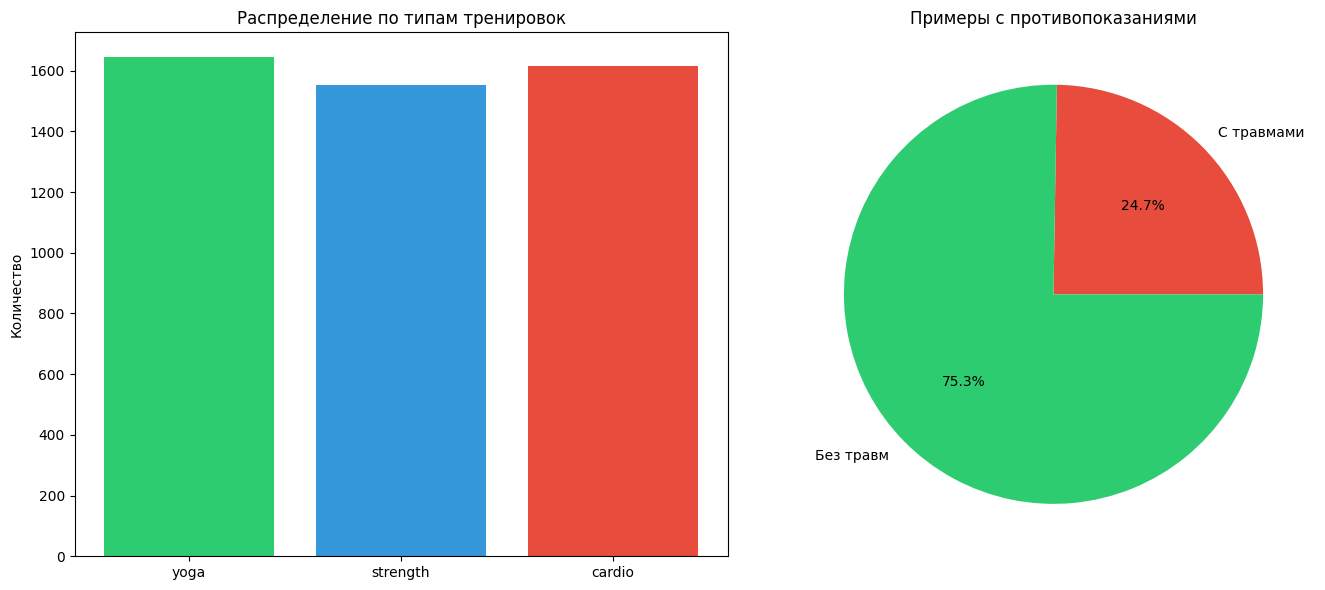

In [8]:
with open("exercises.json", encoding="utf-8") as f:
    CATALOG = json.load(f)
CATALOG_BY_ID = {ex["id"]: ex for ex in CATALOG}
data = load_dataset(".")
plot_coverage(data, CATALOG_BY_ID)